In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy import units as u
from skimage.transform import rescale
from scipy.ndimage import shift
from skimage.transform import rotate
import scipy
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Circle
from scipy.optimize import curve_fit

In [2]:
def pad_image(image, target_shape, pad_value=0):
    """Pad an image to the target shape with a specified pad value.

    Parameters
    ----------
    image : np.ndarray
        The input image to be padded.
    target_shape : tuple
        The desired shape of the output image (height, width).
    pad_value : int, optional
        The value to use for padding, by default 0.

    Returns
    -------
    np.ndarray
        The padded image.
    """
    pad_height = max(0, target_shape[0] - image.shape[0])
    pad_width = max(0, target_shape[1] - image.shape[1])
    
    pad_top = pad_height // 2
    pad_bottom = pad_height - pad_top
    pad_left = pad_width // 2
    pad_right = pad_width - pad_left
    
    padded_image = np.pad(image, 
                        ((pad_top, pad_bottom), (pad_left, pad_right)), 
                        mode='constant', 
                        constant_values=pad_value)
    
    return padded_image

def apply_alignment(img, angle, y_shift, x_shift):
    """Apply rotation and shift to an image."""
    img_rot = rotate(img, angle=angle, resize=False, order=3, preserve_range=True)
    img_shift = shift(img_rot, shift=(y_shift, x_shift), order=3)
    return img_shift

def chi2(fusion_img, mrs_img, angle, y_shift, x_shift):
    fusion_img_rot = rotate(fusion_img, angle=angle, resize=False, order=3, preserve_range=True)  
    fusion_img_shift = shift(fusion_img_rot, shift=(y_shift, x_shift), order=3)  
    fusion_img_masked = fusion_img_shift
    fusion_img_masked = fusion_img_masked
    return np.sum((fusion_img_masked - mrs_img)**2)

def get_result_image(fusion_img, angle, y_shift, x_shift):
    fusion_img_rot = rotate(fusion_img, angle=angle, resize=False, order=3, preserve_range=True)
    fusion_img_shift = shift(fusion_img_rot, shift=(y_shift, x_shift), order=3)
    masked_fusion_img = fusion_img_shift
    return masked_fusion_img



def apply_mask(data, masks, wavelengths):
    """Apply a mask to the data cube.

    Parameters
    ----------
    mask : np.ndarray
        A boolean array with the same spatial dimensions as the data cube.
        True values indicate valid data points, while False values indicate masked points.
    """
    ch_limit = [5.66, 6.53, 7.51, 8.67, 10.02, 11.55, 13.34, 15.41, 17.70, 20.69, 24.19]
    # Apply the mask to each wavelength slice
    w_start = w_stop = 0
    for i in range(masks.shape[0]):
        w_stop = np.where(wavelengths < ch_limit[i])[0][-1] +1
        slice_mask = slice(w_start, w_stop)
        data[slice_mask,:,:] = data[slice_mask,:,:]*masks[i]
        w_start = w_stop

    return data

def gaussian_1d(r, A, sigma, c):
    """Gaussienne 1D : A exp(-r^2/(2 sigma^2)) + c"""
    return A * np.exp(-(r**2) / (2*sigma**2)) + c

def estimate_fwhm(psf_slice, center=None):
    """
    Estime la FWHM d'une PSF 2D en ajustant un profil radial.
    psf_slice : 2D array
    center : (x0, y0), sinon centre du tableau
    """
    ny, nx = psf_slice.shape
    if center is None:
        x0, y0 = nx//2, ny//2
    else:
        x0, y0 = center

    # grille de coordonnées
    y, x = np.indices((ny, nx))
    r = np.sqrt((x - x0)**2 + (y - y0)**2).ravel()
    vals = psf_slice.ravel()

    # tri pour éviter le bruit
    order = np.argsort(r)
    r, vals = r[order], vals[order]

    # normalisation
    vals = vals / vals.max()

    # fit gaussienne radiale
    popt, _ = curve_fit(gaussian_1d, r, vals, p0=[1, 2.0, 0])
    _, sigma, _ = popt

    fwhm = 2.355 * sigma  # conversion sigma -> FWHM
    return fwhm, (x0, y0)



In [3]:

dir = '/home/nmonnier/Projects/JWST/hyper-vista/simulation'
mrs_hdul = fits.open(dir + '/NGC7023_ChannelCube_ch1-2-3-4-shortmediumlong_s3d.fits')
mrs_header = mrs_hdul[1].header 
mrs_data = mrs_hdul[1].data
mrs_data[np.isnan(mrs_data)] = 0

print(f'MRS data shape = {mrs_data.shape}')

res_pix = np.abs(mrs_header['CDELT1'])*u.deg.to(u.arcsec)  # arcsec/pixel
print(mrs_header['CDELT1'])
print(mrs_header['CDELT1']*3600)
print(f"Pixel scale = {res_pix} arcsec/pixel")
scale_factor = (res_pix / 0.1, res_pix / 0.1)

mrs_slice = mrs_data[6517]
mrs_slice[np.isnan(mrs_slice)] = 0

# Nombre de pixels à ajouter
pad_y = 125 - mrs_slice.shape[0]  # = 10
pad_x = 125 - mrs_slice.shape[1]  # = 10

pad_top = pad_y // 2
pad_bottom = pad_y - pad_top
pad_left = pad_x // 2
pad_right = pad_x - pad_left

mrs_padded = np.pad(
    mrs_slice,
    pad_width=((pad_top, pad_bottom), (pad_left, pad_right)),
    mode='constant',
    constant_values=0
)

fusion_hdul = fits.open(dir + '/res_CubeMask.fits')
fusion_header = fusion_hdul[0].header
fusion_data = fusion_hdul[0].data
fusion_mask = fusion_hdul['MASKS'].data
wavelengths = fusion_hdul['WCS-TABLE'].data['wavelength'][0]

fusion_data_masked_all = apply_mask(fusion_data, fusion_mask, wavelengths)

fusion_data_masked = fusion_data[6517] * fusion_mask[6]

norm_fusion = fusion_data_masked/np.max(fusion_data_masked)
norm_mrs = mrs_padded/np.max(mrs_padded)





print("norm fusion shape =", norm_fusion.shape)
print("norm mrs shape =", norm_mrs.shape)
fct_chi2 = lambda x : chi2(norm_fusion, norm_mrs, angle=x[0], y_shift=x[1], x_shift=x[2])
result = scipy.optimize.minimize(
                        fct_chi2, 
                        (0, 0, 0), 
                        method='Nelder-Mead', 
                        options={'disp': True, 'maxiter': 2000, 'maxfev': 5000, 'xatol':1e-3, 'fatol':1e-3},
                            )

print(result)



img = get_result_image(norm_fusion, *result.x)

img_final = np.ascontiguousarray(img.astype(np.float64))
mrs_padded_final = np.ascontiguousarray(mrs_padded.astype(np.float64))

new_mrs_cube = np.zeros((mrs_data.shape[0], fusion_data_masked_all.shape[1], fusion_data_masked_all.shape[2]))
target_shape = (fusion_data_masked_all.shape[1], fusion_data_masked_all.shape[2])
for i in range(new_mrs_cube.shape[0]):
    new_mrs_cube[i] = pad_image(np.ascontiguousarray(mrs_data[i].astype(np.float64)), target_shape, pad_value=0)


# Apply alignment to all slices of the cube
for i in range(fusion_data_masked_all.data.shape[0]):
    fusion_data_masked_all[i] = apply_alignment(np.ascontiguousarray(fusion_data_masked_all[i].astype(np.float64)), *result.x)

PSFs = np.load('/home/nmonnier/Data/JWST/NGC_7023/Fusion/PSF/psfs_pixscale0.1_npix_125_chan_1ABC_2ABC_3ABC_4ABC.npy')


MRS data shape = (10396, 115, 115)
2.77777777777777e-05
0.09999999999999973
Pixel scale = 0.09999999999999973 arcsec/pixel
norm fusion shape = (125, 125)
norm mrs shape = (125, 125)
Optimization terminated successfully.
         Current function value: 101.522614
         Iterations: 125
         Function evaluations: 230
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 101.52261352539062
             x: [ 7.895e-01 -5.512e-01  1.676e+00]
           nit: 125
          nfev: 230
 final_simplex: (array([[ 7.895e-01, -5.512e-01,  1.676e+00],
                       [ 7.890e-01, -5.512e-01,  1.676e+00],
                       [ 7.896e-01, -5.505e-01,  1.675e+00],
                       [ 7.894e-01, -5.511e-01,  1.676e+00]]), array([ 1.015e+02,  1.015e+02,  1.015e+02,  1.015e+02]))


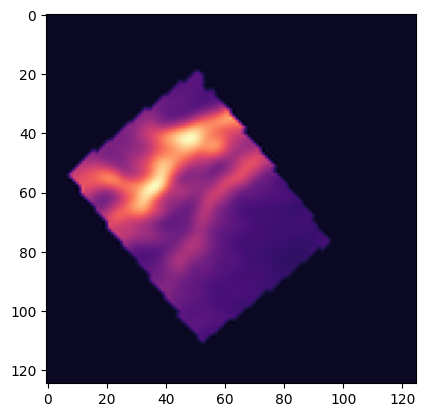

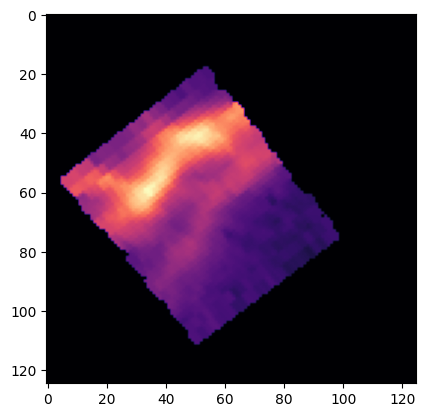

In [4]:
plt.imshow(fusion_data[6517], cmap='magma')
plt.figure()
plt.imshow(new_mrs_cube[6517], cmap='magma')

(107, 17)


/tmp/ipykernel_239216/3768372749.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


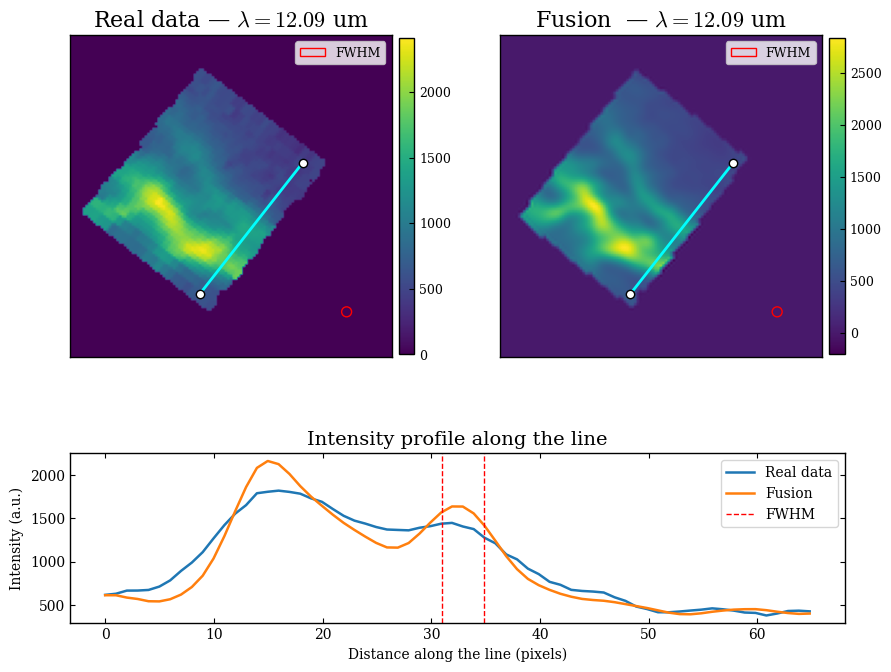

In [5]:
slice_idx = 6517                 # index du slice à afficher
# slice_idx = 50
p1 = (50, 24)                   # point de départ (x, y) en pixels
p2 = (90, 75)                 # point d'arrivée (x, y) en pixels

# new_mrs_cube et fusion_data doivent être définis (shape: (L, H, W))
img1 = new_mrs_cube[slice_idx]      # image MRS (2D)
img2 = fusion_data_masked_all[slice_idx]       # image fusionnée (2D)
psf_slice = PSFs[slice_idx]   # slice correspondante
fwhm, center = estimate_fwhm(psf_slice)
center = (center[0]+45, center[1]-45)  # ajustement du centre à cause du padding
print(center)

# --- S'assurer que les coordonnées sont entières (utile pour l'affichage) ---
p1 = tuple(np.round(p1).astype(int))
p2 = tuple(np.round(p2).astype(int))

# --- Fonction d'extraction du profil le long d'une ligne (même méthode pour les 2 images) ---
def line_profile(img, p1_xy, p2_xy, n_samples=None):
    """
    Retourne le profil d'intensité le long de la ligne reliant p1_xy->p2_xy.
    p1_xy, p2_xy sont des tuples (x,y).
    Utilise skimage.measure.profile_line si disponible, sinon scipy.ndimage.map_coordinates.
    """
    x1, y1 = p1_xy
    x2, y2 = p2_xy
    try:
        # skimage renvoie un tableau dans l'ordre du segment, demande (row, col) = (y,x)
        from skimage.measure import profile_line
        prof = profile_line(img, (y1, x1), (y2, x2), order=1, mode='reflect')
        return prof
    except Exception:
        # fallback: interpolation bilinéaire le long de N points
        from scipy.ndimage import map_coordinates
        if n_samples is None:
            n_samples = int(np.hypot(x2 - x1, y2 - y1)) + 1
        xs = np.linspace(x1, x2, n_samples)
        ys = np.linspace(y1, y2, n_samples)
        coords = np.vstack([ys, xs])  # map_coordinates veut (dim, N)
        prof = map_coordinates(img, coords, order=1, mode='reflect')
        return prof

# --- Extraire les profils (même méthode, donc même longueur) ---
prof_img1 = line_profile(img1, p1, p2)
prof_img2 = line_profile(img2, p1, p2)

# distance en pixels le long de la ligne
length_pixels = np.hypot(p2[0] - p1[0], p2[1] - p1[1])
dist = np.linspace(0.0, length_pixels, len(prof_img1))

# --- Style publication-ready ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# --- Figure : deux images au dessus, profil commun en dessous ---
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.45], hspace=0.25, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])   # image 1 (MRS)
ax2 = fig.add_subplot(gs[0, 1])   # image 2 (Fusion)
ax_prof = fig.add_subplot(gs[1, :])  # profil commun (prend les deux colonnes)

val = float(wavelengths[slice_idx])
val_fmt = f"{val:.4g}"   # 2 chiffres significatifs

# Afficher images (origin='lower' pour que y augmente vers le haut)
im1 = ax1.imshow(img1, cmap='viridis', origin='lower')
ax1.plot([p1[0], p2[0]], [p1[1], p2[1]], color='cyan', lw=2)
ax1.plot(p1[0], p1[1], 'o', color='white', markersize=6, markeredgecolor='k')
ax1.plot(p2[0], p2[1], 'o', color='white', markersize=6, markeredgecolor='k')
ax1.set_title(fr"Real data — $\lambda = {val_fmt}$ um", fontsize=16)
ax1.set_xticks([]); ax1.set_yticks([])
cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02)
cbar1.ax.tick_params(labelsize=9)

im2 = ax2.imshow(img2, cmap='viridis', origin='lower')
ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], color='cyan', lw=2)
ax2.plot(p1[0], p1[1], 'o', color='white', markersize=6, markeredgecolor='k')
ax2.plot(p2[0], p2[1], 'o', color='white', markersize=6, markeredgecolor='k')
ax2.set_title(fr"Fusion  — $\lambda = {val_fmt}$ um", fontsize=16)
ax2.set_xticks([]); ax2.set_yticks([])
cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)
cbar2.ax.tick_params(labelsize=9)

#Add size FWHM to the plot



# Profil commun
ax_prof.plot(dist, prof_img1, lw=1.8, label='Real data')
ax_prof.plot(dist, prof_img2, lw=1.8, label='Fusion')

# plot length of the FWHM
ax_prof.axvline(dist[len(dist)//2]-fwhm/2, color='red', linestyle='--', lw=1, label='FWHM')
ax_prof.axvline(dist[len(dist)//2]+fwhm/2, color='red', linestyle='--', lw=1)
ax_prof.set_xlabel('Distance along the line (pixels)', fontsize=10)
ax_prof.set_ylabel('Intensity (a.u.)', fontsize=10)
ax_prof.set_title('Intensity profile along the line', fontsize=14)
ax_prof.legend(fontsize=10)
ax_prof.grid(False)

for ax in [ax1, ax2]:
    circ = Circle(center, radius=fwhm/2, edgecolor='red', facecolor='none',
                  lw=1, label='FWHM')
    ax.add_patch(circ)
    ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
# plt.savefig(f"/home/nmonnier/Presentations/20250916_INCLASS/profile_{val_fmt}um.png", dpi=300)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_239216/989296389.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


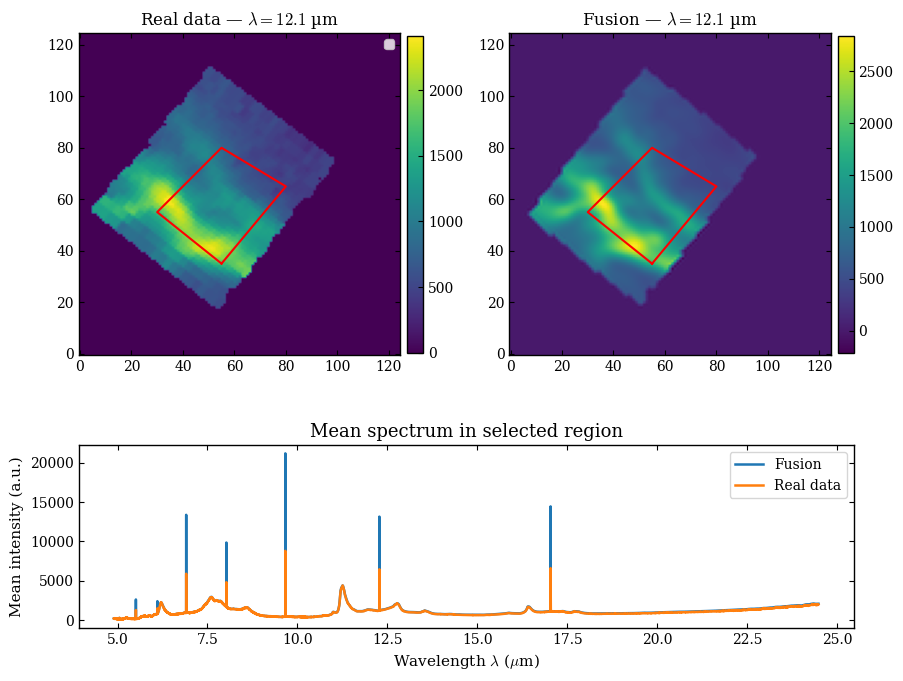

In [6]:
from matplotlib.path import Path

# --- Définition du polygone (4 coins) ---
coords = [(55,35), (80,65), (55,80), (30,55)]  # exemple

def mean_spectrum_in_polygon(cube, coords):
    """
    Retourne le spectre moyen dans la zone polygonale définie par coords.
    cube: (L, H, W)
    coords: liste [(x,y),...]
    """
    ny, nx = cube.shape[1], cube.shape[2]
    y, x = np.mgrid[:ny, :nx]
    points = np.vstack((x.ravel(), y.ravel())).T
    path = Path(coords)
    mask = path.contains_points(points).reshape((ny, nx))
    
    # moyenne des pixels du masque pour chaque slice spectral
    mean_spec = np.nanmean(cube[:, mask], axis=1)
    return mean_spec, mask

# --- Extraction des spectres ---
spec_real, mask_real = mean_spectrum_in_polygon(new_mrs_cube[:fusion_data_masked_all.shape[0]], coords)
spec_fusion, mask_fusion = mean_spectrum_in_polygon(fusion_data_masked_all, coords)

# --- Affichage : 2 images + spectres en dessous ---
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.5], hspace=0.25, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax_spec = fig.add_subplot(gs[1, :])

poly = coords + [coords[0]]

# --- Images avec polygone rouge ---
im1 = ax1.imshow(new_mrs_cube[slice_idx], cmap="viridis", origin="lower")
ax1.plot(*zip(*poly), color="red", lw=1.5)
ax1.set_title(fr"Real data — $\lambda = {wavelengths[slice_idx]:.3g}$ µm", fontsize=12)
ax1.legend(fontsize=9)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02)

im2 = ax2.imshow(fusion_data_masked_all[slice_idx], cmap="viridis", origin="lower")
ax2.plot(*zip(*poly), color="red", lw=1.5)
ax2.set_title(fr"Fusion — $\lambda = {wavelengths[slice_idx]:.3g}$ µm", fontsize=12)
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

# --- Spectres moyens ---
ax_spec.plot(wavelengths, spec_fusion, lw=1.8, label="Fusion")
ax_spec.plot(wavelengths, spec_real, lw=1.8, label="Real data")
ax_spec.set_xlabel(r"Wavelength $\lambda$ ($\mu$m)", fontsize=11)
ax_spec.set_ylabel("Mean intensity (a.u.)", fontsize=11)
ax_spec.set_title("Mean spectrum in selected region", fontsize=13)
ax_spec.legend(fontsize=10)
ax_spec.grid(False)

plt.tight_layout()
# plt.savefig(f"/home/nmonnier/Presentations/20250916_INCLASS/mean_spectrum_fusion_vs_reald_data.png", dpi=300)
plt.show()


3081.4465
3327.3224423396537
-7.389602702996154


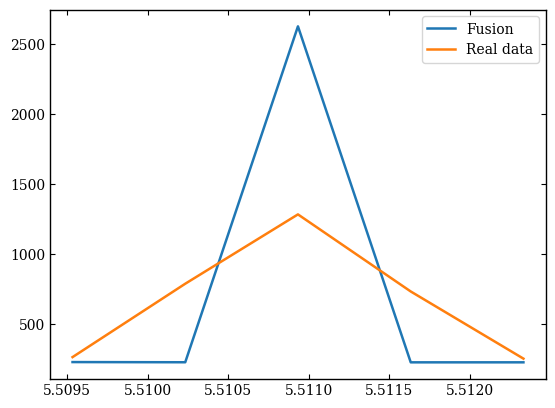

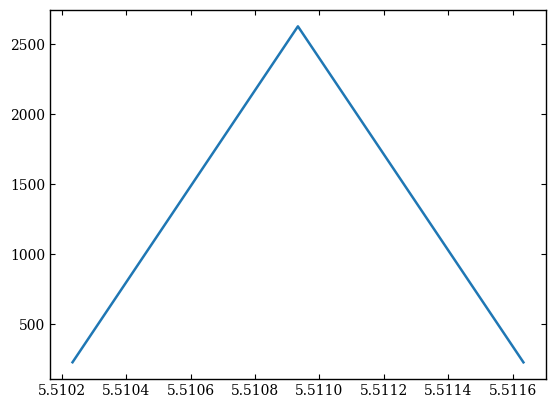

In [24]:
plt.figure()
plt.plot(wavelengths[933:938], spec_fusion[933:938], lw=1.8, label="Fusion")
plt.plot(wavelengths[933:938], spec_real[933:938], lw=1.8, label="Real data")
plt.legend()
plt.figure()
plt.plot(wavelengths[934:937], spec_fusion[934:937], lw=1.8, label="Fusion")
print(np.sum(spec_fusion[934:937]))
print(np.sum(spec_real[933:938]))
print((np.sum(spec_fusion[934:937])-np.sum(spec_real[933:938]))/np.sum(spec_real[933:938])*100)


/tmp/ipykernel_4820/1539925066.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


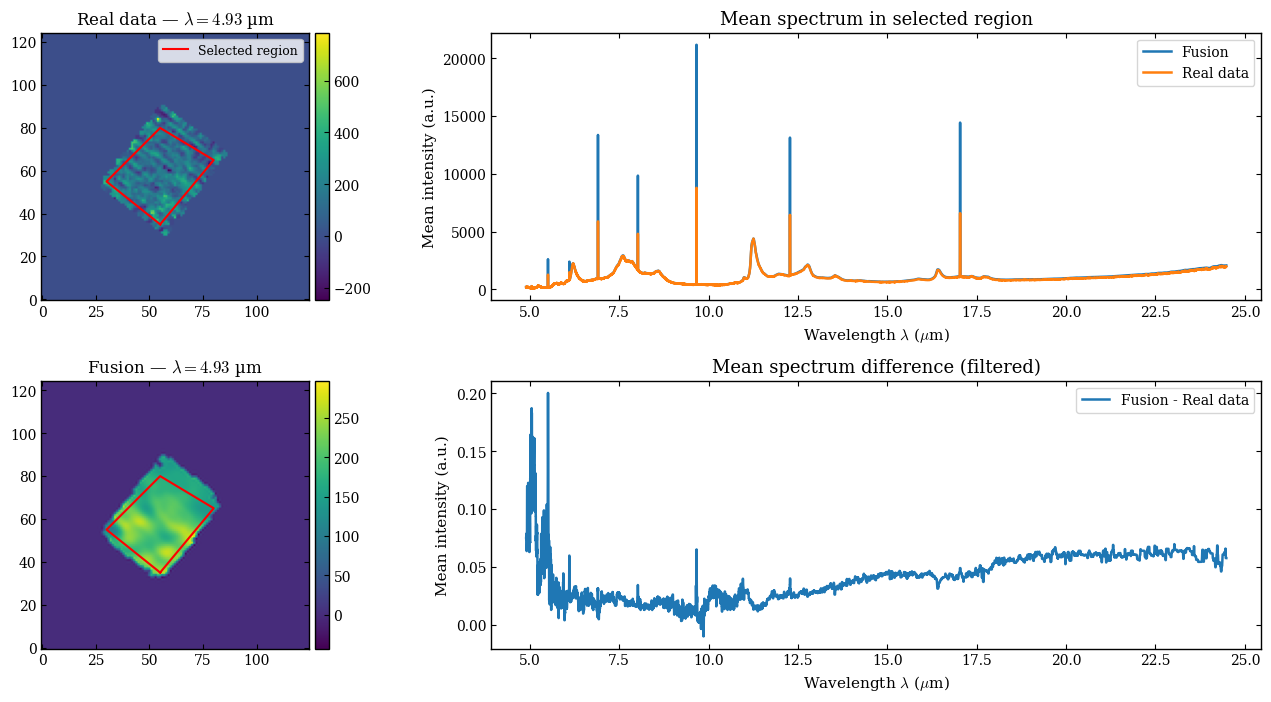

In [18]:
from matplotlib.path import Path

# --- Définition du polygone (4 coins) ---
coords = [(55,35), (80,65), (55,80), (30,55)]  # exemple

def mean_spectrum_in_polygon(cube, coords):
    """
    Retourne le spectre moyen dans la zone polygonale définie par coords.
    cube: (L, H, W)
    coords: liste [(x,y),...]
    """
    ny, nx = cube.shape[1], cube.shape[2]
    y, x = np.mgrid[:ny, :nx]
    points = np.vstack((x.ravel(), y.ravel())).T
    path = Path(coords)
    mask = path.contains_points(points).reshape((ny, nx))
    
    # moyenne des pixels du masque pour chaque slice spectral
    mean_spec = np.nanmean(cube[:, mask], axis=1)
    return mean_spec, mask

# --- Extraction des spectres ---
spec_real, mask_real = mean_spectrum_in_polygon(new_mrs_cube[:fusion_data_masked_all.shape[0]], coords)
spec_fusion, mask_fusion = mean_spectrum_in_polygon(fusion_data_masked_all, coords)

fig = plt.figure(figsize=(16, 8))
# colonne gauche étroite (images), colonne droite large (plots)
gs = fig.add_gridspec(2, 2, width_ratios=[1, 2.5], hspace=0.3, wspace=0.3)

ax_img1 = fig.add_subplot(gs[0, 0])  # image réelle
ax_img2 = fig.add_subplot(gs[1, 0])  # image fusion
ax_spec = fig.add_subplot(gs[0, 1])  # spectres
ax_diff = fig.add_subplot(gs[1, 1])  # différences

poly = coords + [coords[0]]

# --- Image réelle ---
im1 = ax_img1.imshow(new_mrs_cube[slice_idx], cmap="viridis", origin="lower")
ax_img1.plot(*zip(*poly), color="red", lw=1.5, label="Selected region")
ax_img1.set_title(fr"Real data — $\lambda = {wavelengths[slice_idx]:.3g}$ µm", fontsize=12)
ax_img1.legend(fontsize=9)
fig.colorbar(im1, ax=ax_img1, fraction=0.046, pad=0.02)

# --- Image fusionnée ---
im2 = ax_img2.imshow(fusion_data_masked_all[slice_idx], cmap="viridis", origin="lower")
ax_img2.plot(*zip(*poly), color="red", lw=1.5)
ax_img2.set_title(fr"Fusion — $\lambda = {wavelengths[slice_idx]:.3g}$ µm", fontsize=12)
fig.colorbar(im2, ax=ax_img2, fraction=0.046, pad=0.02)

# --- Spectres moyens ---
ax_spec.plot(wavelengths, spec_fusion, lw=1.8, label="Fusion")
ax_spec.plot(wavelengths, spec_real, lw=1.8, label="Real data")
ax_spec.set_xlabel(r"Wavelength $\lambda$ ($\mu$m)", fontsize=11)
ax_spec.set_ylabel("Mean intensity (a.u.)", fontsize=11)
ax_spec.set_title("Mean spectrum in selected region", fontsize=13)
ax_spec.legend(fontsize=10)
ax_spec.grid(False)

# --- Différence ---
from scipy import ndimage
ax_diff.plot(
    wavelengths,
    ndimage.median_filter((spec_fusion - spec_real)/spec_fusion, size=15),
    lw=1.8,
    label="Fusion - Real data"
)
ax_diff.set_xlabel(r"Wavelength $\lambda$ ($\mu$m)", fontsize=11)
ax_diff.set_ylabel("Mean intensity (a.u.)", fontsize=11)
ax_diff.set_title("Mean spectrum difference (filtered)", fontsize=13)
ax_diff.legend(fontsize=10)
ax_diff.grid(False)

plt.tight_layout()
# plt.savefig(f"/home/nmonnier/Presentations/20250916_INCLASS/mean_spectrum_fusion_vs_reald_data.png", dpi=300)
plt.show()

